# Data Analysis Techniques. Lab 2. Working with `numpy`, part 2

In [1]:
import numpy as np
from timeit import timeit

## 1. Array copies and array views

### 1.1 Examples and main differences

When referring to a specific part of an existing NumPy array, we may sometimes be dealing with a **view** and sometimes with a **copy**. In some cases, we can control which of these two types of objects is returned for a given operation, and in others, we cannot. 

If we take a closer look at the internal organization of NumPy arrays, we’ll find that they consist of a contiguous block of memory arranged in the same order as the elements in the array. This area is also of fixed size due to the data type and array size being specified at the time of creation. Because computer memory is one-dimensional, arrays—which, as we know, can be multidimensional—are stored in strides, the size of which is calculated based on the array’s shape and data type. Strides are defined for each dimension, which allows for fast reading and manipulation of data along a given axis (dimension).

More detailed information regarding the internal organization of NumPy arrays can be found here:

* https://numpy.org/doc/stable/dev/internals.html#numpy-internals
* https://www.labri.fr/perso/nrougier/from-python-to-numpy/#anatomy-of-an-array

In [2]:
# initializing array to be used in examples
A = np.arange(1, 5).reshape((2,2))
A

array([[1, 2],
       [3, 4]])

In [3]:
# Let's esplore some of the array's features
# 1. base - returns the object with which it shares memory, or `None` if it does not share memory
# https://numpy.org/doc/2.2/reference/generated/numpy.ndarray.base.html
A.base

array([1, 2, 3, 4])

In [4]:
# size of one element (bytes)
A.itemsize

8

In [5]:
A.dtype

dtype('int64')

In [6]:
# number of elements in an array
A.size

4

In [7]:
# which might be used to calculate the memory used for array data allocation
A.itemsize * A.size

32

In [8]:
# which might be directly accessed within nbytes property
A.nbytes

32

In [9]:
A

array([[1, 2],
       [3, 4]])

In [10]:
# Two slices that point to the same element, but as you can see, one of them
# does not share memory with the object from which it was sliced, while the other does
# The first is a copy, and the second is a view
x = A[0][0] # 1
x_1 = A[:1, 0] # also 1
x_2 = A[[0]][0][0] # this is also 1
x.base, x_1.base, x_2.base

(None, array([1, 2, 3, 4]), None)

In [11]:
x_2

np.int64(1)

In [12]:
x_2

np.int64(1)

In [13]:
# Functions taken from https://tobiasraabe.github.io/post/numpy-views-vs-copies/
# These functions make it easier to determine whether two NumPy arrays have a common base
# which means they share memory (or not)

def get_data_base(x):
    """ get a base of a given array """
    base = x
    while isinstance(base.base, np.ndarray):
        base = base.base
    return base

def arrays_share_data(x, y):
    """ compare object's identity """
    return get_data_base(x) is get_data_base(y)

In [14]:
# First, let’s take another look at the two previous objects
arrays_share_data(x, A), arrays_share_data(x_1, A), arrays_share_data(x_2, A)

(False, True, False)

&#128165;&#128165;&#128165;&#128165;&#128165;  
Here, it’s worth remembering one rule that was presented in the previous example. Regular slices return a view, while complex slices (known as fancy indexing) return a copy.

You can read more about fancy indexing here, for example: https://jakevdp.github.io/PythonDataScienceHandbook/02.07-fancy-indexing.html

Below are a few additional examples.

In [15]:
AA = np.random.random((5,5))
AA

array([[0.72554074, 0.53981114, 0.9520279 , 0.7196729 , 0.12933168],
       [0.3283298 , 0.13356308, 0.23442177, 0.0674692 , 0.22037163],
       [0.791799  , 0.19287633, 0.21573469, 0.22256857, 0.68033715],
       [0.08909009, 0.8334515 , 0.0409066 , 0.91622288, 0.04107688],
       [0.86124802, 0.6639035 , 0.45363117, 0.05955856, 0.62962634]])

In [16]:
AA > 0.5 # boolean map

array([[ True,  True,  True,  True, False],
       [False, False, False, False, False],
       [ True, False, False, False,  True],
       [False,  True, False,  True, False],
       [ True,  True, False, False,  True]])

In [17]:
arrays_share_data(AA[AA > 0.5], AA)

False

In [18]:
arrays_share_data(AA[:,::2], AA)

True

In [19]:
arrays_share_data(AA[:,::2], AA), arrays_share_data(AA[:, [0,2,4]], AA)

(True, False)

In [20]:
# this slice is a view
x_3 = A[0]
print(x_3)
arrays_share_data(x_3, A)

[1 2]


True

In [21]:
x_3.ndim

1

In [22]:
# ten wycinek też jest widokiem, ale zwróć uwagę na shape
# this slice is also a view, but look at its shape
x_4 = A[:1] # first "row"
print(x_4)
arrays_share_data(x_4, A)

[[1 2]]


True

In [23]:
x_4.ndim

2

In [24]:
# structure and data look the same, but this time this is a copy
x_5 = A[:1, [0,1]]
print(x_5)
arrays_share_data(x_5, A)

[[1 2]]


False

In [25]:
# identical data as in x_5, but it is a copy as well
x_6 = A[[0], ]
print(x_6)
arrays_share_data(x_6, A)

[[1 2]]


False

In [26]:
# If we specify a list of multiple indices that we want
# to reference, we will get a copy of the array
arrays_share_data(A[[0,1]], A)

False

In [27]:
# However, if it is a slice or an ellipsis (...), we will get the following view
arrays_share_data(A[...], A)

True

In [28]:
# Even though x_7 and x_8 look almost identical in notation (tuple vs. list)
# the results they return differ in terms of shape
x_7 = A[(0,)]
print(x_7)
arrays_share_data(x_7, A)

[1 2]


True

In [29]:
x_8 = A[[0,]]
print(x_8)
arrays_share_data(x_8, A)

[[1 2]]


False

In [30]:
# This is because the ellipsis is omitted, and the two snippets below are equivalent
x_9 = A[0,]
print(x_9, A[0])
arrays_share_data(x_9, A),arrays_share_data(A[0], A)

[1 2] [1 2]


(True, True)

An interesting fact is that changing the shape of an array does not necessarily imply any changes to its elements, although this is not guaranteed according to the documentation at https://numpy.org/doc/stable/reference/generated/numpy.reshape.html.

Some changes to the parameters of a NumPy array alter its metadata (parameters) that define the properties describing it, rather than the location of the data itself in memory.

Below is an example using our array A.

In [31]:
B = A.reshape((4,))
B

array([1, 2, 3, 4])

In [32]:
A

array([[1, 2],
       [3, 4]])

In [33]:
arrays_share_data(B, A)

True

In [34]:
B.base is A.base

True

In [35]:
B.base, A.base

(array([1, 2, 3, 4]), array([1, 2, 3, 4]))

In [36]:
A, B

(array([[1, 2],
        [3, 4]]),
 array([1, 2, 3, 4]))

I probably don’t need to explain that copies will allocate additional memory and take up more CPU time, unlike views.

Does that mean views are good and copies are bad? Absolutely not. Each has its own uses; the important thing is to use them thoughtfully.

Below are a few examples of how they can be used.

### View vs copy and data insertion

In [37]:
Z = np.zeros(9)
print(Z)
Z_view = Z[:3]
Z_view[...] = 1

[0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [38]:
Z

array([1., 1., 1., 0., 0., 0., 0., 0., 0.])

In [39]:
Z, Z_view

(array([1., 1., 1., 0., 0., 0., 0., 0., 0.]), array([1., 1., 1.]))

In [40]:
Z_view

array([1., 1., 1.])

In [41]:
arrays_share_data(Z, Z_view)

True

In [42]:
Z = np.zeros(9)
Z_copy = Z[[0,1,2]]
Z_copy[...] = 1

In [43]:
Z

array([0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [44]:
Z_copy

array([1., 1., 1.])

In [45]:
arrays_share_data(Z, Z_copy)

False

### Using a given part of numpy array with mathematical operations

In [46]:
C = np.arange(100_000_000).reshape((10_000,10_000))

In [47]:
C.nbytes

800000000

In [48]:
C_1 = C[:5000,:5000]

In [49]:
# let's make sure if it is a view
arrays_share_data(C_1, C)

True

In [50]:
C_1.shape, C_1.size, C_1.mean()

((5000, 5000), 25000000, np.float64(24997499.5))

In [51]:
# using a given indexes for data selection
idx = range(5000)
C_2 = C[idx, :5000]

In [52]:
# and this time we have a copy
arrays_share_data(C_2, C)

False

In [53]:
# This attribute allows you to examine certain array attributes related to the memory allocated for it
# C_CONTIGUOUS indicates C-style memory contiguity
# F_CONTIGUOUS indicates Fortran-style memory contiguity
# OWNDATA specifies whether the array shares data with another array (False means its base is a reference to another array) or whether it owns the data (True)
# WRITEABLE specifies whether the data in the array can be overwritten (default is True); you can set this flag to False to prevent overwriting.
# This is also possible for views created from this array, even if the original array allows data in that area to be overwritten.
# ALIGNED indicates whether the data is properly aligned for the hardware
# WRITEBACKIFCOPY indicates whether it is a copy of another table (according to the documentation), but this concept is somewhat more complex, and I refer the reader to the documentation
C.flags

  C_CONTIGUOUS : True
  F_CONTIGUOUS : False
  OWNDATA : False
  WRITEABLE : True
  ALIGNED : True
  WRITEBACKIFCOPY : False

In [54]:
!pip install pandas

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [55]:
import pandas as pd
df = pd.DataFrame(np.random.random((5,5)))

In [56]:
df

,0,1,2,3,4
0,0.266321,0.499170,0.993859,0.639545,0.099454
1,0.921614,0.498837,0.982896,0.418293,0.595920
2,0.691991,0.500965,0.786833,0.691333,0.949919
3,0.469271,0.192255,0.549124,0.782521,0.875889
4,0.568051,0.648650,0.223695,0.243538,0.787972


In [57]:
C_1.flags

  C_CONTIGUOUS : False
  F_CONTIGUOUS : False
  OWNDATA : False
  WRITEABLE : True
  ALIGNED : True
  WRITEBACKIFCOPY : False

In [58]:
C_2.flags

  C_CONTIGUOUS : True
  F_CONTIGUOUS : False
  OWNDATA : True
  WRITEABLE : True
  ALIGNED : True
  WRITEBACKIFCOPY : False

In [59]:
# Another way to check whether arrays share data is to verify whether a given element that we extracted from the original
# (assuming that a view was created as a result) has the same memory identifier as the corresponding element in the original array
# Why is indexing in the second case performed along a single dimension? The answer is in the cell below—the base is visible as a
# one-dimensional array
id(C[0][0]) == id(C_1.base[0])

True

In [60]:
C.shape, C_1.base.shape, C_1.shape

((10000, 10000), (100000000,), (5000, 5000))

In [61]:
id(C), id(C_1.base)

(132634294165424, 132634294168208)

In [62]:
C_2.shape, C_2.size, C_2.mean()

((5000, 5000), 25000000, np.float64(24997499.5))

**And one more example with flags and views**

In [63]:
# we are creating two new arrays
D = np.arange(25)
E = D[:5]

In [64]:
# We see data continuity in both styles (dimensions) (typically for one-dimensional arrays)
D.flags, E.flags

(  C_CONTIGUOUS : True
   F_CONTIGUOUS : True
   OWNDATA : True
   WRITEABLE : True
   ALIGNED : True
   WRITEBACKIFCOPY : False,
   C_CONTIGUOUS : True
   F_CONTIGUOUS : True
   OWNDATA : False
   WRITEABLE : True
   ALIGNED : True
   WRITEBACKIFCOPY : False)

In [65]:
# identifiers are also identical
id(D), id(E.base)

(132633143152432, 132633143152432)

In [66]:
# now we are changing shape of the base array and overwriting the D variable
D = D.reshape((5,5))

In [67]:
# let's check the identifiers once again - no match this time
id(D), id(E.base)

(132633143153296, 132633143152432)

In [68]:
# but base for array E looks somehow familiar
E.base

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24])

In [69]:
E

array([0, 1, 2, 3, 4])

In [70]:
# array are actually sharing the data
arrays_share_data(E, D)

True

In [71]:
# let's check object id's for first element of both arrays
id(D[0][0]), id(E[0])

(132633143279728, 132633143279728)

In [72]:
# identifiers match, but flags show certain differences between variables
print(D.flags)
print(E.base.flags)
print(E.flags)

  C_CONTIGUOUS : True
  F_CONTIGUOUS : False
  OWNDATA : False
  WRITEABLE : True
  ALIGNED : True
  WRITEBACKIFCOPY : False

  C_CONTIGUOUS : True
  F_CONTIGUOUS : True
  OWNDATA : True
  WRITEABLE : True
  ALIGNED : True
  WRITEBACKIFCOPY : False

  C_CONTIGUOUS : True
  F_CONTIGUOUS : True
  OWNDATA : False
  WRITEABLE : True
  ALIGNED : True
  WRITEBACKIFCOPY : False



In [73]:
# This happens because of the `reshape()` function, which returns a new view of the data from the array, changing its dimensions whenever possible
# or creating a copy if necessary
# This means that NumPy refers to the base array created by calling, for example, arange(25), which created a one-dimensional array
# consisting of 25 consecutive elements starting from the value 0

# If we check the following, we will get confirmation
id(D.base), id(E.base)

(132633143152432, 132633143152432)

### 1.2 Performance comparison

We will use the `timeit` module to measure the average execution time of selected code snippets.

In [74]:
from timeit import timeit
# For our measurements, we will use our arrays C, C_1, and C_2
# Here, we will measure the time required to access the area with dimensions (5000, 5000) in the base array C
# We are using slices, but the first is a view and the second is a copy

setup = """
import numpy as np
C = np.arange(100_000_000).reshape((10_000,10_000))
"""

stmt_1 = """
C_1 = C[:5000,:5000]
"""

stmt_2 = """
idx = range(5000)
C_2 = C[idx, :5000]
"""

timeit(stmt_1, setup=setup, number=1000), timeit(stmt_2, setup=setup, number=1000)

(0.00037025599976914236, 62.02493124700004)

As you can see, simply creating a variable with access to the specified data is several orders of magnitude faster with views than with copies, which seems obvious given the cost of accessing already reserved memory and reallocating it (in this case, for multiple values).
We will try to measure some other sample operations as well.

In [75]:
# let's measure time of calculating the mean value for both arrays

setup = """
import numpy as np
C = np.arange(100_000_000).reshape((10_000,10_000))
"""

stmt_1 = """
C[:5000,:5000].mean()
"""

stmt_2 = """
idx = range(5000)
C[idx, :5000].mean()
"""

timeit(stmt_1, setup=setup, number=100), timeit(stmt_2, setup=setup, number=100)

(2.995167398999911, 8.783485147999272)

In the example above, the results are closer, but the first case is still faster—about 4 times faster in this instance. Keep in mind that in addition to the shorter execution time, we also save memory here, which is important for larger datasets, especially when we approach or exceed the RAM limit, which in the next phase results in the use of disk storage, which is usually much slower than RAM.

**np.view function**

The `np.view` function allows you to create a view of the original NumPy array, whose elements can be “viewed” in a different format than the original. Here is an example.

In [76]:
D = np.arange(10)

In [77]:
D.dtype

dtype('int64')

In [78]:
E = D.view(np.int32)

In [79]:
E.base

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [80]:
arrays_share_data(D,E)

True

In [81]:
D.dtype, E.dtype

(dtype('int64'), dtype('int32'))

In [82]:
D.nbytes, E.nbytes

(80, 80)

In [83]:
E.size

20

In [84]:
E

array([0, 0, 1, 0, 2, 0, 3, 0, 4, 0, 5, 0, 6, 0, 7, 0, 8, 0, 9, 0],
      dtype=int32)

In [85]:
CC = np.array([(2**16)-1 for _ in range(5)], dtype=np.uint16)
CC

array([65535, 65535, 65535, 65535, 65535], dtype=uint16)

In [86]:
DD = CC.view(np.int8)

In [87]:
arrays_share_data(DD, CC)

True

In [88]:
DD

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1], dtype=int8)

## 2. Selected `numpy` functions

### 2.1 Changing shape of an array

**numpy.reshape()**

In [89]:
A = np.ones(16)

In [90]:
# 1. we know it already
A.reshape((4,4))

array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]])

In [91]:
# we can call this function like that as well
A.reshape(4,4)

array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]])

In [92]:
A.reshape((2,2,4))

array([[[1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.]]])

In [93]:
# with reshape we can choose wheter we want a copy or a view as a returned value
B = A.reshape((4,4), copy=True)
print(B)
arrays_share_data(B,A)

[[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]


False

In [94]:
# The `reshape` function allows us to set an “unknown” value for only one of the axes by specifying the value -1
# which flattens the data
print(B.reshape(-1))

print(B.reshape(2,-1))
print(B.reshape(2,2,-1))

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[[1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]]
[[[1. 1. 1. 1.]
  [1. 1. 1. 1.]]

 [[1. 1. 1. 1.]
  [1. 1. 1. 1.]]]


**numpy.ravel()**

In [95]:
# returns a one-dimensional array created from the specified base array
np.ravel(B)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [96]:
# Most functions can also be called from within an object instance, such as an ndarray
B.ravel()

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [97]:
arrays_share_data(B.ravel(), B)

True

In [98]:
# view or copy?
arrays_share_data(B, B.ravel())

True

**numpy.ndarray.flatten()**

In [99]:
# It works similarly to `ravel`, but since it is a method of the `ndarray` class, it is called from within the object
B.flatten()

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [100]:
# view or copy?
arrays_share_data(B, B.flatten())

False

**numpy.ndarray.flat**

In [101]:
# returns an iterator that allows you to iterate through an array element by element, as if it were a one-dimensional array
B.flat

In [102]:
B[0] = [1,2,3,4]

In [103]:
B, B.T

(array([[1., 2., 3., 4.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]]),
 array([[1., 1., 1., 1.],
        [2., 1., 1., 1.],
        [3., 1., 1., 1.],
        [4., 1., 1., 1.]]))

In [104]:
arrays_share_data(B, B.T)

True

There are other options as well, such as using `rot90`, `flip`, `fliplr`, and `flipud`, but I'll leave those for the reader to explore.

### 2.2 Merging `numpy` arrays

In [105]:
A = np.arange(1, 6)
B = np.arange(6, 11)
A, B

(array([1, 2, 3, 4, 5]), array([ 6,  7,  8,  9, 10]))

In [106]:
# I think something went wrong?
# It definitely works for lists, but for n-darrays, for example, the __add__ operator (i.e., +) behaves differently
# It performs an element-wise operation—that is, element by element
# broadcasting
A + B

array([ 7,  9, 11, 13, 15])

In [107]:
# This means that the following won't work—the dimensions don't match
A + np.arange(3)

ValueError: operands could not be broadcast together with shapes (5,) (3,) 

In [108]:
# To concatenate arrays, we need to use different methods; here, we use `concatenate`
np.concatenate((A,B))

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [109]:
GG = np.arange(9).reshape((3,3))
GG

array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]])

In [110]:
np.mean(GG)

np.float64(4.0)

In [111]:
np.mean(GG, axis=1)

array([1., 4., 7.])

In [112]:
# This function also takes an argument called `axis`, which is quite common in the NumPy library and specifies the axis
# along which the operation is to be performed (this will come up many times)
C = np.arange(4).reshape(2,2)
D = np.arange(4,8).reshape(2,2)
print(np.concatenate((C,D), axis=1), np.concatenate((C,D), axis=1).shape)
print(np.concatenate((C,D), axis=0), np.concatenate((C,D), axis=0).shape)

[[0 1 4 5]
 [2 3 6 7]] (2, 4)
[[0 1]
 [2 3]
 [4 5]
 [6 7]] (4, 2)


In [113]:
df.to_numpy().mean(axis=0)

array([0.5834496 , 0.46797536, 0.70728125, 0.55504593, 0.66183094])

In [114]:
# np.stack also concatenates arrays, but creates a new dimension in the resulting array
# by default, axis=0
print(np.stack((C,D)))
print(np.stack((C,D)).shape)

[[[0 1]
  [2 3]]

 [[4 5]
  [6 7]]]
(2, 2, 2)


In [115]:
# and for axis=1 we have
print(np.stack((C,D), axis=1))
print(np.stack((C,D), axis=1).shape)

[[[0 1]
  [4 5]]

 [[2 3]
  [6 7]]]
(2, 2, 2)


In [116]:
# we can also stack array horizontally
print(np.hstack((C,D)))
print(np.hstack((C,D)).shape)

[[0 1 4 5]
 [2 3 6 7]]
(2, 4)


In [117]:
# or vertical
print(np.vstack((C,D)))
print(np.vstack((C,D)).shape)

[[0 1]
 [2 3]
 [4 5]
 [6 7]]
(4, 2)


In [118]:
# We can also stack arrays of different sizes, but there are, of course, limitations
E = np.vstack((C,D))
np.vstack((E,C))

array([[0, 1],
       [2, 3],
       [4, 5],
       [6, 7],
       [0, 1],
       [2, 3]])

In [119]:
F = np.arange(8).reshape(4,2)
np.vstack((F,C))
# np.hstack((F,C)) # error!

array([[0, 1],
       [2, 3],
       [4, 5],
       [6, 7],
       [0, 1],
       [2, 3]])

## 3. Summary

Operation | Result | Reason
| --- | --- | --- |
b = a[0:5] | View| Simple slice of a continuous block
“b = a[[0, 2]]”| Copy| Fancy indexing (selective indices)
b = a[a > 5]| Copy| Logical indexing (mask)
“b = a.reshape(2, -1)”| View*| Change in dimension interpretation
b = a.T| View| Stride swap
b = a.flatten()| Copy| “Guaranteed new, flat array”
b = a.ravel()| View| “Tries not to copy if possible”

### Example of using numpy and Pillow imaging library

In [120]:
!pip install Pillow

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [121]:
from PIL import Image

In [122]:
arr_img = np.repeat(np.arange(256), 256).reshape((256,256)).astype(np.uint8)

In [123]:
arr_img

array([[  0,   0,   0, ...,   0,   0,   0],
       [  1,   1,   1, ...,   1,   1,   1],
       [  2,   2,   2, ...,   2,   2,   2],
       ...,
       [253, 253, 253, ..., 253, 253, 253],
       [254, 254, 254, ..., 254, 254, 254],
       [255, 255, 255, ..., 255, 255, 255]], shape=(256, 256), dtype=uint8)

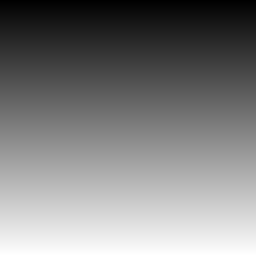

In [124]:
img = Image.fromarray(arr_img, mode='L')
img.show()

You can play with the example changing its pixels to your needs.

## Tasks

**Task 1**

Create a NumPy array of size (4,4) filled with values ranging from 2 to 32 in increments of 2, and assign it to a variable.
Display its data type, the number of elements, the size of a single element, and the amount of memory allocated.





In [125]:
import numpy as np

# Task 1: 4x4 array: 2,4,...,32
task1 = np.arange(2, 34, 2).reshape(4, 4)
print(task1)
print("dtype:", task1.dtype)
print("number of elements:", task1.size)
print("bytes per item:", task1.itemsize)
print("total bytes:", task1.nbytes)



[[ 2  4  6  8]
 [10 12 14 16]
 [18 20 22 24]
 [26 28 30 32]]
dtype: int64
number of elements: 16
bytes per item: 8
total bytes: 128


**Task 2**

Return the array from Exercise 1 as a view.
Change its data type (you can do this using the `astype()` function, for example) to `uint8`.
Now check whether the array is a view or a copy of the original array. Display the number of elements, the size of a single element, and the amount of memory allocated.





In [126]:
import numpy as np

# Task 2: view of Task 1, then uint8 version
task1 = np.arange(2, 34, 2).reshape(4, 4)
task_view = task1.view()
small = task_view.astype(np.uint8)

print("Shares memory with task1:", np.shares_memory(task1, small))
print("Owns its own data buffer:", small.flags["OWNDATA"])
print("dtype:", small.dtype)
print("elements:", small.size)
print("itemsize:", small.itemsize)
print("nbytes:", small.nbytes)



Shares memory with task1: False
Owns its own data buffer: True
dtype: uint8
elements: 16
itemsize: 1
nbytes: 16


**Task 3**

Cut out a 2 x 2 area “from the center” of the array from Exercise 1 (values 12, 14, 20, 22) in two ways:
* one as a view and assign it to a variable
* the other as a copy and assign it to a variable

Using the examples from class, check whether the bases of these two arrays are different (they should be).





In [127]:
import numpy as np

task1 = np.arange(2, 34, 2).reshape(4, 4)
center_view = task1[1:3, 1:3]
center_copy = task1[1:3, 1:3].copy()
print("view:\n", center_view)
print("copy:\n", center_copy)
print("view is tied to base:", center_view.base is not None)
print("copy has no base:", center_copy.base is None)



view:
 [[12 14]
 [20 22]]
copy:
 [[12 14]
 [20 22]]
view is tied to base: True
copy has no base: True


**Task 4**

Create a 4x4 matrix containing the values 1, 2, 3, and 4 in each row.
Then, using array concatenation functions, create an array by concatenating the above array and its horizontal mirror image (try using slices). The form of each row after concatenation: `[1 2 3 4 4 3 2 1]`





In [128]:
import numpy as np

# Task 4: each row 1,2,3,4 then mirror horizontally
row = np.array([1, 2, 3, 4])
matrix = np.tile(row, (4, 1))
mirror = row[::-1]
right_side = np.tile(mirror, (4, 1))
full = np.concatenate([matrix, right_side], axis=1)
print(full)



[[1 2 3 4 4 3 2 1]
 [1 2 3 4 4 3 2 1]
 [1 2 3 4 4 3 2 1]
 [1 2 3 4 4 3 2 1]]


**Task 5**

Create a 2x2 array named `Z_5` filled with the value 1.
Using array concatenation functions, create an array that will ultimately consist of 4 `Z_5` arrays, such that the final result is a 4x4 array similar to the one below:

1,1,2,2  
1,1,2,2  
3,3,4,4  
3,3,4,4  



In [129]:
import numpy as np

# Task 5: four 2x2 blocks with values 1..4
Z_5 = np.ones((2, 2))
b1 = Z_5 * 1
b2 = Z_5 * 2
b3 = Z_5 * 3
b4 = Z_5 * 4
top = np.concatenate([b1, b2], axis=1)
bottom = np.concatenate([b3, b4], axis=1)
big = np.concatenate([top, bottom], axis=0)
print(big)



[[1. 1. 2. 2.]
 [1. 1. 2. 2.]
 [3. 3. 4. 4.]
 [3. 3. 4. 4.]]
